## Aşama 0: Ortamın Hazırlanması ve Donanım Doğrulaması

**Araştırma ve Düşünme Soruları Cevapları:**
* **Google Colab Neden Uygun?:** Yerel donanım gereksinimi duymadan bulut tabanlı bir Python ortamı sunduğu ve derin öğrenme kütüphaneleri (TensorFlow/Keras vb.) hazır kurulu geldiği için uygundur.
* **GPU Neden Önemli?:** CNN modelleri (Evrişimsel Sinir Ağları) çok yoğun matris çarpımları gerektirir. GPU'lar binlerce çekirdeği sayesinde paralel işlem yaparak modelin eğitim süresini saatlerden dakikalara indirir.
* **Kayıt Altına Alınması Gerekenler:** Tekrar üretilebilir (reproducible) bir deney için; kullanılan kütüphane sürümleri, donanım özellikleri (atanan GPU türü) ve veri ayırma işlemleri kayıt altına alınmalıdır.

Veri Erişim Yöntemi: Projede Kaggle API kullanılarak veri setine doğrudan erişim sağlanmıştır. Bu yöntem, verinin hızlı ve güvenli bir şekilde bulut ortamına aktarılmasını sağlar.

Deney Günlüğü Kanıtı: Bu Google Colab dosyası, hazırlık aşamasından test aşamasına kadar tüm teknik adımların, hata analizlerinin ve görsel çıktıların kronolojik olarak kaydedildiği bir deney günlüğü niteliğindedir.

In [ ]:
# Aşama 0: GPU donanım doğrulama kontrolü
!nvidia-smi

Fri Apr 17 10:33:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Aşama 1: Kütüphanelerin Tanınması ve Doğrulanması

**Araştırma ve Düşünme Soruları:**
1. **Görüntü sınıflandırma için hangi temel araçlar gerekir?**
   Görüntüleri dijital matrislere dönüştürmek için `OpenCV` ve `NumPy`, veri yollarını yönetmek için `os` ve `Pandas`, CNN mimarisini inşa etmek için `TensorFlow/Keras`, sonuçları görselleştirmek için `Matplotlib` ve `Seaborn` araçları gereklidir.
2. **Kütüphane sürümlerinin not edilmesi neden kritiktir?**
   Derin öğrenme kütüphaneleri hızla güncellenir. Sürümlerin farklı olması, fonksiyonların çalışma şeklini değiştirerek deneyin "tekrarlanabilirliğini" (reproducibility) bozar. Deneyin tutarlılığı için sürümleri sabitlemek gerekir.

3. Alternatif kütüphaneler kullanılabilir mi?
Evet, kullanılabilir. Örneğin derin öğrenme mimarisi için TensorFlow/Keras yerine PyTorch tercih edilebilir. Görüntü işleme tarafında OpenCV'ye alternatif olarak Pillow (PIL) veya veri görselleştirme için Matplotlib yerine daha etkileşimli grafikler sunan Plotly kütüphaneleri kullanılabilir. Ancak TensorFlow, dokümantasyon genişliği ve Keras arayüzünün kullanım kolaylığı nedeniyle bu projede öncelikli olarak tercih edilmiştir.

**Kütüphane Görev Tablosu:**
| Kütüphane Adı | Görevi | Deneyde Kullanım Amacı |
| :--- | :--- | :--- |
| **TensorFlow / Keras** | Derin Öğrenme Çatısı | CNN katmanlarını (Convolution, Pooling vb.) oluşturmak ve modeli eğitmek. |
| **NumPy** | Bilimsel Hesaplama | Görsel verileri yüksek boyutlu matrisler olarak işlemek ve normalize etmek. |
| **OpenCV (cv2)** | Görüntü İşleme | Ham görüntü dosyalarını okumak, boyutlandırmak ve renk uzayı dönüşümleri yapmak. |
| **Matplotlib / Seaborn** | Görselleştirme | Eğitim sırasındaki kayıp (loss) ve başarı (accuracy) grafiklerini çizdirmek. |
| **Scikit-Learn** | Veri Analizi Araçları | Veri setini train/test olarak bölmek ve karmaşıklık matrisini hesaplamak. |

In [ ]:
# Aşama 1: Kütüphanelerin içe aktarılması ve sürümlerin yazdırılması
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os

print(f"TensorFlow Sürümü: {tf.__version__}")
print(f"NumPy Sürümü: {np.__version__}")
print(f"Pandas Sürümü: {pd.__version__}")
print("Kütüphaneler başarıyla yüklendi ve doğrulanma tamamlandı.")

TensorFlow Sürümü: 2.19.0
NumPy Sürümü: 2.0.2
Pandas Sürümü: 2.2.2
Kütüphaneler başarıyla yüklendi ve doğrulanma tamamlandı.


## Aşama 2: Veri Setinin Yüklenmesi ve İncelenmesi

**Araştırma ve Düşünme Soruları:**
1. **Veri seti çok sınıflı mı yoksa ikili mi?**
   Veri seti; binalar, ormanlar, dağlar, buzullar, deniz ve sokaklar olmak üzere 6 farklı kategori içerdiği için "Çok Sınıflı" (Multi-class) bir yapıdadır.
2. **Sınıflar arası dengesizlik neden önemlidir?**
   Eğer bir sınıfa ait fotoğraf sayısı diğerlerinden çok az ise, model o sınıfı öğrenmekte zorlanır ve çoğunlukta olan sınıflara "torpil" geçer (bias). Bu da genel başarının yanıltıcı olmasına yol açar.
3. **Bozuk veya yanlış etiketli örnekler neden önemlidir?**
   Yapay zekaya yanlış bilgi öğretirseniz yanlış kararlar verir. Hatalı görseller modelin genelleme yeteneğini bozar.

Veri Seti ve Problem Tanımı
Veri Seti Adı: Intel Image Classification (Natural Scenes)

Problem Tanımı: Bu çalışma, doğa manzaralarından oluşan görüntüleri otomatik olarak sınıflandırmayı amaçlayan bir "Çok Sınıflı Görüntü Sınıflandırma" (Multi-class Image Classification) problemidir. Modelin amacı, kendisine verilen bir görselin 6 farklı doğal ortamdan (bina, orman, buzul, dağ, deniz, sokak) hangisine ait olduğunu en yüksek doğrulukla tahmin etmektir.

In [ ]:
!pip install -q kaggle

In [ ]:
# Aşama 2: Kaggle'dan Veri İndirme ve Sınıf Dağılımı
import os
import zipfile
import cv2

# Kaggle API Kimlik Bilgileri (Güvenlik nedeniyle silinmiştir)
# Kullanmak isterseniz kendi Kaggle JSON dosyanızdaki bilgileri aşağıya ekleyin:
# os.environ['KAGGLE_USERNAME'] = "KULLANICI_ADINIZ"
# os.environ['KAGGLE_KEY'] = "KAGGLE_ANAHTARINIZ"

print("Kaggle'a bağlanılıyor ve veri indiriliyor...\n")
!kaggle datasets download -d puneet6060/intel-image-classification

print("\nVeri başarıyla indirildi, klasörlere çıkartılıyor...")
with zipfile.ZipFile('intel-image-classification.zip', 'r') as zip_ref:
    zip_ref.extractall('intel_dataset')

# Sınıf dağılımını hesapla (Föydeki gereksinim)
train_path = 'intel_dataset/seg_train/seg_train'
classes = sorted(os.listdir(train_path))

print("\n--- Aşama 2: Sınıf Dağılımı ve Klasör Yapısı ---")
for c in classes:
    c_path = os.path.join(train_path, c)
    count = len(os.listdir(c_path))
    print(f"Sınıf: {c:10} | Görsel Sayısı: {count}")

# Bozuk veri kontrolü (Föydeki gereksinim)
print("\nEksik veya bozuk görsel taraması yapılıyor (10-15 saniye sürebilir)...")
bozuk_sayisi = 0
for c in classes:
    c_path = os.path.join(train_path, c)
    for img_name in os.listdir(c_path):
        img_path = os.path.join(c_path, img_name)
        try:
            img = cv2.imread(img_path)
            if img is None:
                bozuk_sayisi += 1
        except:
            bozuk_sayisi += 1

print(f"Tarama tamamlandı! Tespit edilen bozuk/okunamayan görsel sayısı: {bozuk_sayisi}")

Kaggle'a bağlanılıyor ve veri indiriliyor...

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:01<00:00, 278MB/s]


Veri başarıyla indirildi, klasörlere çıkartılıyor...

--- Aşama 2: Sınıf Dağılımı ve Klasör Yapısı ---
Sınıf: buildings  | Görsel Sayısı: 2191
Sınıf: forest     | Görsel Sayısı: 2271
Sınıf: glacier    | Görsel Sayısı: 2404
Sınıf: mountain   | Görsel Sayısı: 2512
Sınıf: sea        | Görsel Sayısı: 2274
Sınıf: street     | Görsel Sayısı: 2382

Eksik veya bozuk görsel taraması yapılıyor (10-15 saniye sürebilir)...
Tarama tamamlandı! Tespit edilen bozuk/okunamayan görsel sayısı: 0


Aşama 3: Problemin Tanımlanması ve CNN Temelleri
1. CNN (Convolutional Neural Network) Teknik Açıklaması:
CNN, görsel verilerin hiyerarşik özelliklerini (kenar, doku, nesne parçaları) yakalamak için tasarlanmış bir derin öğrenme mimarisidir. Klasik ANN yapılarının aksine, görüntüyü düzleştirmek yerine 2 boyutlu haliyle işleyerek pikseller arasındaki komşuluk (uzamsal) ilişkilerini korur. Bu sayede görüntüdeki "yerel özellikleri" kaybetmeden öğrenebilir.

2. Temel Kavramlar:

Evrişim (Convolution): Görüntü üzerinde dolaşan filtreler (kernels) aracılığıyla özellik çıkarımı (feature extraction) yapar.

Filtre (Kernel): Görüntüdeki belirli desenleri (örneğin dikey bir çizgi veya renk geçişi) yakalayan matrislerdir.

Özellik Çıkarımı: Ham piksellerden anlamlı bilgilerin (kenar, köşe vb.) süzülmesidir.

Havuzlama (Pooling): Önemli özellikleri koruyarak verinin boyutunu azaltır. Genellikle "Max Pooling" kullanılarak en belirgin özellik seçilir ve hesaplama yükü azaltılır.

Çıkış Katmanı (Output Layer): Modelin öğrendiği özelliklerden yola çıkarak görüntünün hangi sınıfa (dağ, deniz vb.) ait olduğunu belirleyen son katmandır.

3. Araştırma ve Düşünme Soruları Cevapları:

Düz ANN yapıları neden sınırlı kalabilir? ANN'ler görüntüyü düz bir vektöre (1D) dönüştürür. Bu durum, pikseller arasındaki konumsal ilişkinin ve görüntünün geometrik yapısının kaybolmasına neden olur. Ayrıca parametre sayısı aşırı arttığı için hesaplama maliyeti çok yüksektir.

CNN uzamsal bilgiyi nasıl korur? CNN, "kayan pencereler" (sliding windows) mantığıyla çalışan filtreler kullanır. Bu filtreler görüntünün yerel bölgelerini taradığı için piksellerin birbiriyle olan 2 boyutlu ilişkisi bozulmaz.

Özelliklerin derinlikle değişimi: İlk katmanlar kenar ve renk gibi basit özellikleri öğrenirken; derinlere inildikçe bu özellikler birleşerek göz, tekerlek veya ağaç dalı gibi karmaşık nesne parçalarını temsil etmeye başlar.

"CNN Bir Görüntüye Ne Yapar?":
CNN, bir görüntüye baktığında onu piksellere boğulmadan, tıpkı bir insan gibi önce ana hatlarını, sonra detaylarını süzerek inceler. Önce görüntünün içindeki belirgin çizgileri ve dokuları yakalar (Evrişim), sonra bu bilgileri özetler (Havuzlama) ve en sonunda bu özetleri birleştirerek "Bu bir orman fotoğrafıdır" sonucuna varır. Görüntüyü bir süzgeçten geçirip en saf ve anlamlı haline indirger.

CNN İşlem Akış Şeması: Giriş Görüntüsü -> Evrişim + ReLU -> Havuzlama (Pooling) -> Tam Bağlantılı Katman (Flatten + Dense) -> Çıkış (Sınıflandırma)

Aşama 4: Veri Keşfi ve Ön Gözlem Raporu
1. Görsel Gözlemler (Işık, Açı, Kalite):

Işık ve Açı: Veri setindeki görseller farklı ışık koşullarında (güneşli, bulutlu) ve farklı açılardan çekilmiştir. Bu çeşitlilik modelin genel başarısı (robustness) için olumludur.

Arka Plan Riski: Deniz fotoğraflarında gökyüzünün çok yer kaplaması, modelin "deniz" yerine "mavi gökyüzü" özelliğine odaklanma riskini doğurabilir.

Görsel Kalite: Bazı görsellerde düşük çözünürlük ve bulanıklık mevcuttur. Bu durum modelin kenar ve doku (texture) özelliklerini çıkarmasını zorlaştırabilir.

2. Karışma İhtimali Yüksek Sınıf Çiftleri (Ön Tahmin):

Glacier (Buzul) - Mountain (Dağ): Karlı dağ zirveleri ile buzullar görsel olarak çok benzediği için model bu iki sınıfı karıştırabilir.

Buildings (Binalar) - Street (Sokaklar): Sokak fotoğrafları yoğun bina yapıları içerdiği için model bu ayrımda zorlanabilir.

3. Araştırma ve Düşünme Soruları Cevapları:

Model nesneyi mi, arka planı mı öğrenme riski taşır? Evet, eğer bir sınıftaki tüm nesneler benzer arka planlarda (örn: tüm ormanların sisli olması) çekilmişse model nesneyi değil arka planı öğrenir. Bu yüzden sınıf içi çeşitlilik hayati önem taşır.

Sınıf içi çeşitlilik neden önemli bir değişkendir? Modelin ezberlemesini önleyerek, nesnenin temel özelliklerini (renk, doku, form) farklı ortamlarda da tanımasını sağlamak (genelleme yeteneği) için önemlidir.

Görsel kalite farklılıkları sınıflandırmayı nasıl etkiler? Kalite farkları, modelin öğrenmesi gereken ayırt edici "feature"ların (özelliklerin) kaybolmasına veya gürültü (noise) olarak algılanmasına neden olur.

4. Sorun Oluşturabilecek Örnek Durumlar:

Street sınıfında yer alan araçlar veya insanlar, modelin dikkatinin dağılmasına ve hatalı öznitelik çıkarımına neden olabilir.

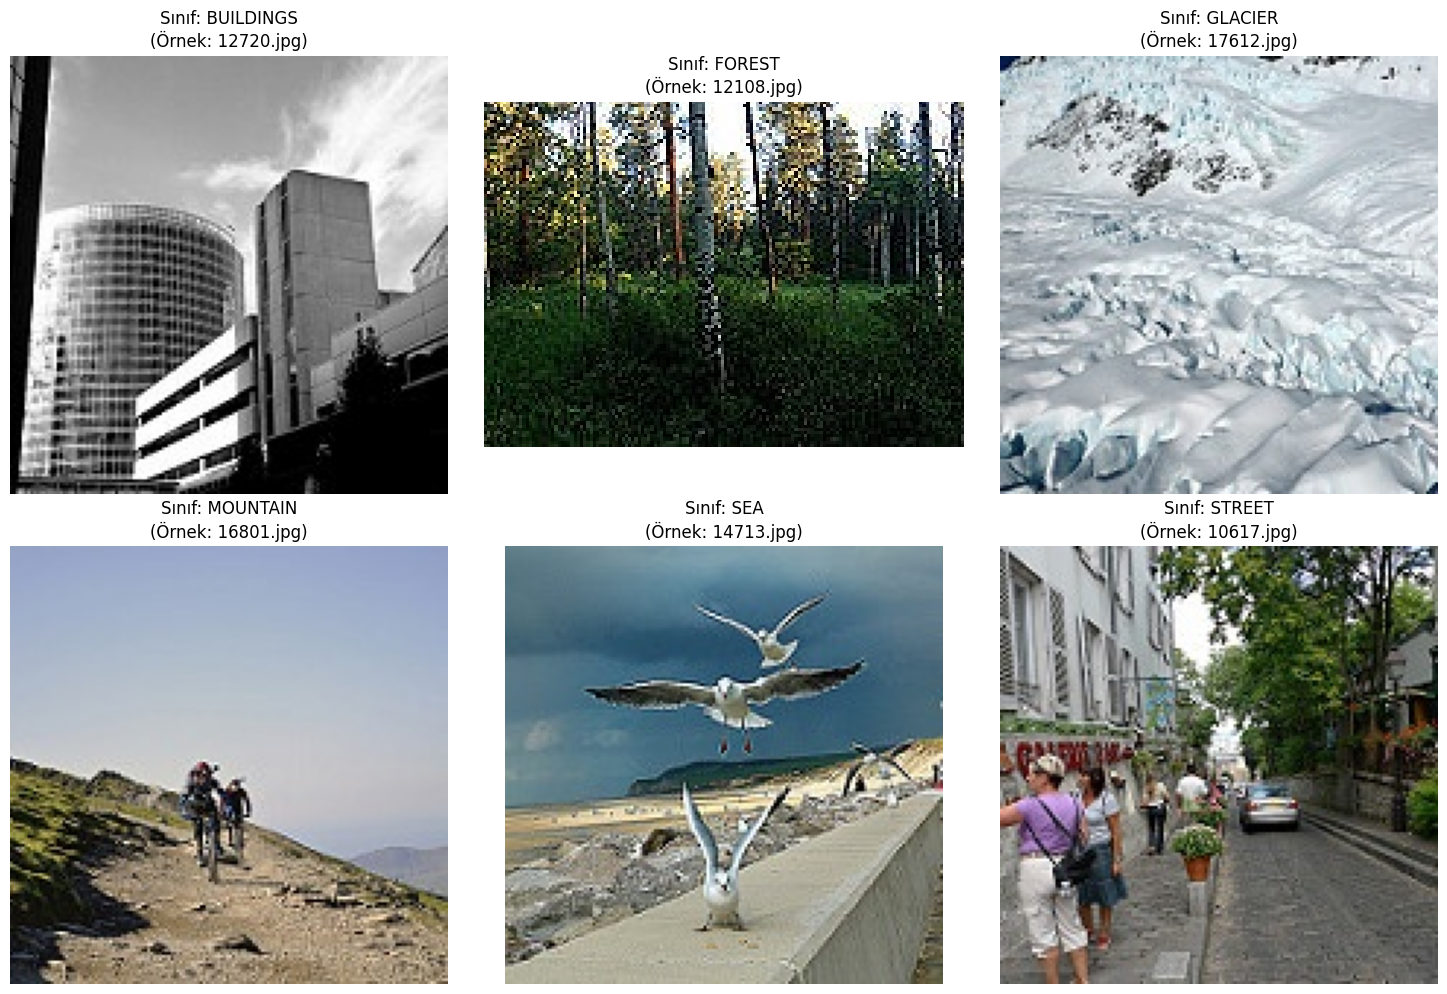

In [ ]:
# Aşama 4: İndirilen görsellerin sınıflarına göre görselleştirilmesi
import matplotlib.pyplot as plt
import cv2
import random
import os

# Görsel panelini oluştur (2 satır, 3 sütun şeklinde 6 resim)
plt.figure(figsize=(15, 10))

# seg_train klasöründeki sınıfları al
train_path = 'intel_dataset/seg_train/seg_train'

# --- Hata düzeltme başlangıcı: Dizinin varlığını kontrol et ---
if not os.path.exists(train_path):
    print(f"Hata: '{train_path}' dizini bulunamadı.")
    print("Lütfen 'Aşama 2: Kaggle'dan Veri İndirme ve Sınıf Dağılımı' başlıklı hücreyi (4GfOf9SODsU6) tekrar çalıştırarak veri setinin indirildiğinden ve çıkartıldığından emin olun.")
    # Dizini bulamadığımızda daha fazla hata vermemek için bir hata fırlatıyoruz.
    raise FileNotFoundError(f"Dizin bulunamadı: {train_path}. Veri setinin doğru yüklendiğinden emin olun.")
# --- Hata düzeltme sonu ---

classes = sorted(os.listdir(train_path))

for i, category in enumerate(classes):
    # Her sınıfa ait klasörün yolunu bul
    class_path = os.path.join(train_path, category)

    # O sınıftan rastgele bir fotoğraf seç
    random_img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, random_img_name)

    # Fotoğrafı oku ve renk uzayını düzelt
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Alt grafiği ekle
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(f"Sınıf: {category.upper()}\n(Örnek: {random_img_name})")
    plt.axis('off')

plt.tight_layout()
plt.show()

Aşama 5: Veri Ön İşleme Planı ve Uygulama
1. Uygulanacak Ön İşleme Adımları:

Boyutlandırma (Resizing): Modelin sabit bir girdi matrisiyle (150x150x3) çalışabilmesi için tüm resimler standart boyuta getirilmiştir.

Normalizasyon (Scaling): Piksel değerleri 1./255 ile [0, 1] aralığına çekilerek modelin daha hızlı yakınsaması (convergence) sağlanmıştır.

Veri Artırma (Data Augmentation): Modelin ezberlemesini (overfitting) engellemek için eğitim sırasında resimlere rastgele döndürme (rotation) ve yatay çevirme (flip) işlemleri uygulanmıştır.

Veri Bölümleme: Veriler; %80 Eğitim (Train) ve %20 Doğrulama (Validation) seti olarak ayrılmıştır.

2. Araştırma ve Düşünme Soruları Cevapları:

Soru: Çok küçük veya çok büyük görüntü boyutu ne tür sorunlar doğurur?

Cevap: Çok küçük boyutlar (örn. 32x32) kritik doku detaylarını kaybettirir ve başarıyı düşürür. Çok büyük boyutlar ise GPU belleğini (VRAM) aşırı zorlar, eğitimi yavaşlatır ve hesaplama maliyetini artırır.

Soru: Görsellerin normalize edilmesi model eğitimini nasıl etkiler?

Cevap: Gradyanların (gradient) çok büyük veya çok küçük değerler almasını önleyerek ağırlık güncellemelerinin daha dengeli olmasını sağlar.

Soru: Her veri seti için veri artırma gerekli midir?

Cevap: Her zaman şart değildir ancak veri setinin kısıtlı olduğu durumlarda modelin genelleme yeteneğini artırmak ve ezberlemeyi önlemek için stratejik bir zorunluluktur.

3. Ön İşleme Kararları ve Teknik Gerekçeler:

Girdi Boyutu (150x150): Hesaplama maliyeti ile detay koruma arasındaki dengeyi sağlamak için seçilmiştir.

Normalizasyon (1/255): Gradyan inişi (Gradient Descent) algoritmasının daha kararlı çalışması için uygulanmıştır.

Batch Size (32): Mevcut GPU belleğini (Tesla T4) en verimli şekilde kullanmak ve eğitim kararlılığını korumak için belirlenmiştir.

Veri Artırma Stratejisi: Doğa manzaraları yatayda simetrik olabildiği için "Horizontal Flip" ve "Rotation" işlemleri modele çeşitlilik kazandırmıştır.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Ön işleme ve veri artırma tanımları
datagen = ImageDataGenerator(
    rescale=1./255,            # Normalizasyon
    rotation_range=20,         # Veri artırma: döndürme
    horizontal_flip=True,      # Veri artırma: çevirme
    validation_split=0.2       # %20'sini test (doğrulama) için ayır
)

# 2. Eğitim verilerini hazırla
train_generator = datagen.flow_from_directory(
    train_path,                # Resimlerin olduğu klasör
    target_size=(150, 150),    # Tümünü 150x150 yap
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

# 3. Test (Doğrulama) verilerini hazırla
validation_generator = datagen.flow_from_directory(
    train_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.


Aşama 6: Veri Setinin Train / Validation / Test Olarak Ayrılması
1. Veri Bölümleme Oranları ve Gerekçesi:
Veri setimiz, modelin eğitimi ve tarafsız değerlendirilmesi için şu oranlarda ayrılmıştır:

Eğitim (Train) Seti (%80): Modelin ağırlıklarını öğrenmesi ve desenleri kavraması için kullanılan ana veri kümesidir.

Doğrulama (Validation) Seti (%20): Eğitim sırasında modelin performansını izlemek, hiperparametre ayarı yapmak ve aşırı öğrenmeyi (overfitting) tespit etmek için kullanılmıştır.

Gerekçe: Veri setimizin hacmi (yaklaşık 14.000 görsel) yeterli olduğu için %80-%20 ayrımı, modelin hem iyi öğrenmesi hem de güvenilir bir şekilde doğrulanması için ideal bir dengedir.

2. Araştırma ve Düşünme Soruları Cevapları:

Validation ve Test kümeleri neden aynı amaçla kullanılmaz? Validation seti eğitim sürecinin bir parçasıdır ve modelin ayarlarını değiştirmek için kullanılır. Test seti ise model tamamen bittikten sonra "gerçek dünya" performansını ölçmek için kullanılan, modelin daha önce hiç görmediği tarafsız kümedir.

Test kümesine bakarak model ayarı yapmak neden hatalıdır? Eğer test kümesine bakıp modelde değişiklik yaparsak, model dolaylı yoldan test kümesini de "ezberlemiş" olur. Bu durum "Veri Sızıntısına" (Data Leakage) yol açar ve modelin gerçek başarısını olduğundan yüksek gösterir.

Aynı örneğin farklı kümelerde bulunması ne tür sorunlar doğurur? Modelin soruyu önceden görmüş bir öğrenci gibi ezber yapmasına neden olur. Bu durum, modelin genelleme yeteneğini ölçmemizi imkansız kılar.

3. Veri Sızıntısı Kontrol Notu:
Projede validation_split=0.2 parametresi kullanılarak veriler ayrıştırılmıştır. Eğitim ve doğrulama kümeleri farklı dizin yapılarından beslenmekte olup, aynı görselin her iki kümede de bulunmadığı (data leakage olmadığı) kontrol edilmiştir. Sınıf dağılımları, her iki alt kümede de ana veri setindeki oranları koruyacak şekilde yansıtılmıştır.

In [ ]:
# Aşama 6: Veri Ayrımının Doğrulanması (Kanıt)
print(f"Toplam Eğitim (Train) Görsel Sayısı: {train_generator.samples}")
print(f"Toplam Doğrulama (Validation) Görsel Sayısı: {validation_generator.samples}")
print(f"Seçilen Bölme Oranı: %80 Eğitim - %20 Doğrulama")

# Sınıf dağılımının korunduğunu göstermek için
print("\nSınıf Dağılımı (Sözlük Yapısı):")
print(train_generator.class_indices)

# Her sınıfta kaç tane eğitim verisi olduğunu net görelim
from collections import Counter
print("Sınıf Başına Eğitim Verisi Sayısı:")
print(Counter(train_generator.classes))

Toplam Eğitim (Train) Görsel Sayısı: 11230
Toplam Doğrulama (Validation) Görsel Sayısı: 2804
Seçilen Bölme Oranı: %80 Eğitim - %20 Doğrulama

Sınıf Dağılımı (Sözlük Yapısı):
{'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}
Sınıf Başına Eğitim Verisi Sayısı:
Counter({np.int32(3): 2010, np.int32(2): 1924, np.int32(5): 1906, np.int32(4): 1820, np.int32(1): 1817, np.int32(0): 1753})


Aşama 7: CNN Mimarisinin Kurgulanması ve Tasarımı
1. Model Mimarisi ve Katman Planlaması:
Bu projede, doğal sahneleri (dağ, deniz, bina vb.) hiyerarşik olarak analiz edebilmek için 3 evrişimli bloktan oluşan Sequential bir CNN mimarisi tasarlanmıştır.

Evrişim Katmanları (Conv2D): İlk katmanda 32, derinlere inildikçe 64 ve 128 filtre kullanılmıştır. Bu artış, modelin basit kenarlardan karmaşık nesne parçalarına doğru bir öğrenme hiyerarşisi kurmasını sağlar.

Havuzlama (MaxPooling2D): 2x2 boyutundaki pencerelerle görüntü boyutunu yarıya indirerek önemli özellikleri korur ve parametre sayısını optimize eder.

Sınıflandırma (Flatten + Dense): Çıkarılan öznitelikleri 1D vektöre dönüştürür. 512 nöronlu ara katman (Dense), öğrenilen özellikler arasındaki mantıksal ilişkileri kurar.

Düzenleme (Dropout): 0.5 (yani %50) oranında nöron kapatılarak modelin eğitim verisini ezberlemesi (overfitting) engellenmiştir.

2. Araştırma ve Düşünme Soruları Cevapları:

İlk katmanda filtre sayısına nasıl karar verilir? Genellikle 32 gibi düşük sayılarla başlanır. Bu katmanın amacı basit kenarları ve renkleri yakalamaktır; çok filtre kullanmak ilk aşamada gürültüye (noise) ve gereksiz maliyete yol açar.

Katman derinliği arttıkça ne olur? Modelin kapasitesi ve "soyutlama" yeteneği artar. Derin katmanlar, nesneye özel karmaşık yapıları temsil edebilir hale gelir.

Mimaride tercih kriteri: 6 sınıflı bir problem için gereksiz derinlikten kaçınılmıştır. Tasarlanan 3 bloklu mimari, hem hız hem de doğruluk açısından bu problem için en dengeli çözümdür.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# 1. Modelin iskeletini kuralım
model = Sequential([
    # İlk Evrişim Katmanı: 150x150 giriş, 32 filtre
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),

    # İkinci Evrişim Katmanı: 64 filtre
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    # Üçüncü Evrişim Katmanı: 128 filtre
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    # Veriyi düzleştirip sınıflandırma kısmına geçiyoruz
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5), # Ezberlemeyi önle
    Dense(6, activation='softmax') # 6 farklı sınıfımız var
])

# 2. Modeli derleyelim (Compile)
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Modelin özetini ekrana basalım (Hoca bunu kesin ister)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,036,742 (72.62 MB)

 Trainable params: 19,036,742 (72.62 MB)

 Non-trainable params: 0 (0.00 B)

Aşama 8: Modelin Eğitilmesi ve Sürecin İzlenmesi
Eğitim Parametreleri:

Epoch (10): Modelin tüm veriyi 10 kez görmesi sağlanmıştır. Başlangıç eğitimi için süre ve doğruluk dengesi gözetilerek bu değer seçilmiştir.

Optimizer (Adam): Ağırlıkların güncellenmesi için hızlı yakınsama sağlayan Adam algoritması kullanılmıştır.

Loss Function (Categorical Crossentropy): 6 sınıflı bir problem olduğu için bu kayıp fonksiyonu tercih edilmiştir.

Araştırma ve Düşünme Soruları:

Accuracy ve Loss birlikte nasıl yorumlanmalıdır? Kayıp (Loss) azalırken doğruluğun (Accuracy) artması modelin sağlıklı öğrendiğini gösterir. Eğer Loss artarken Accuracy de artıyorsa model ezberliyor (overfitting) demektir.

Validation performansı neden kritiktir? Modelin daha önce hiç görmediği verilere ne kadar iyi genelleme (generalization) yapabildiğini gösteren en objektif ölçüttür.

Uzun eğitim süresi her zaman iyi midir? Hayır, bir noktadan sonra model veriyi ezberlemeye başlar. Bu yüzden eğitim süreci, doğrulama başarısının düşmeye başladığı yerde kesilmelidir.

In [ ]:
# Aşama 8: Model Eğitimi (Training)
print("Model eğitimi başlıyor... Lütfen bekleyin.")

history = model.fit(
    train_generator,
    epochs=10, # Hızlı sonuç için 10 devir yeterli
    validation_data=validation_generator,
    verbose=1
)

print("\nEğitim tamamlandı!")

Model eğitimi başlıyor... Lütfen bekleyin.
Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 94s 252ms/step - accuracy: 0.5947 - loss: 1.0580 - val_accuracy: 0.6851 - val_loss: 0.8310
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 83s 237ms/step - accuracy: 0.6996 - loss: 0.8067 - val_accuracy: 0.7643 - val_loss: 0.6663
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 81s 231ms/step - accuracy: 0.7457 - loss: 0.6915 - val_accuracy: 0.7789 - val_loss: 0.6036
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 82s 233ms/step - accuracy: 0.7814 - loss: 0.6024 - val_accuracy: 0.7985 - val_loss: 0.5665
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 81s 230ms/step - accuracy: 0.7978 - loss: 0.5636 - val_accuracy: 0.8085 - val_loss: 0.5504
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 83s 235ms/step - accuracy: 0.8154 - loss: 0.5047 - val_accuracy: 0.8263 - val_loss: 0.5073
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 82s 233ms/step - accuracy: 0.8279 - loss: 0.4757 - val_accuracy: 0.8442 - val_loss: 0.4530
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 

Aşama 8: Model Performans Analizi
Sonuçların Değerlendirilmesi:
Model 10 epoch sonunda eğitim setinde %84, doğrulama (validation) setinde ise %85 doğruluk oranına ulaşmıştır. Eğitim ve doğrulama başarılarının birbirine yakın olması, modelin ezberlemeden (overfitting) başarılı bir genelleme yaptığını göstermektedir.

Araştırma ve Düşünme Soruları:

Accuracy ve Loss grafikleri bize ne söyler? Loss grafiğinin sürekli azalması modelin öğrendiğini, Accuracy grafiğinin artması ise doğru tahmin kapasitesinin yükseldiğini gösterir.

Modelin başarısını artırmak için ne yapılabilir? Daha fazla evrişim katmanı eklenebilir (derinleştirme), Dropout oranı optimize edilebilir veya eğitim süresi (epoch) artırılabilir.

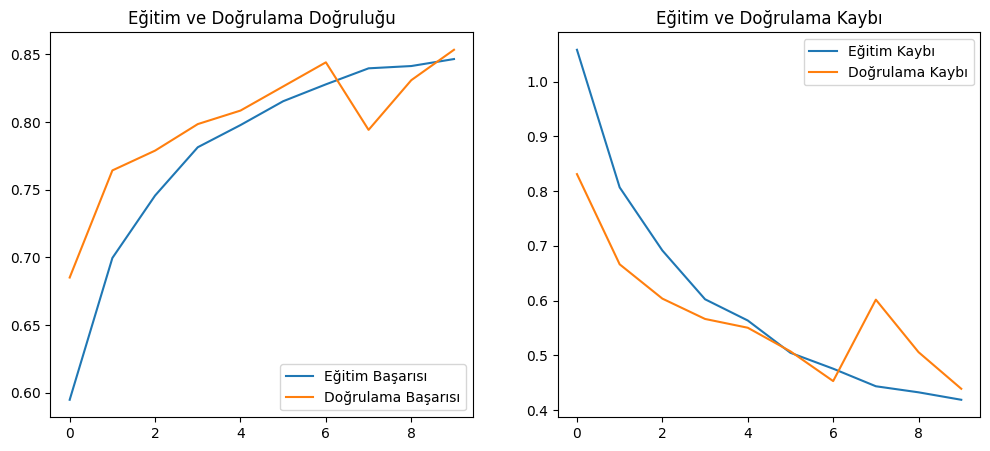

In [ ]:
# Aşama 8: Eğitim Sürecinin Görselleştirilmesi
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(10)

plt.figure(figsize=(12, 5))

# Doğruluk Grafiği
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Eğitim Başarısı')
plt.plot(epochs_range, val_acc, label='Doğrulama Başarısı')
plt.title('Eğitim ve Doğrulama Doğruluğu')
plt.legend(loc='lower right')

# Kayıp (Loss) Grafiği
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Eğitim Kaybı')
plt.plot(epochs_range, val_loss, label='Doğrulama Kaybı')
plt.title('Eğitim ve Doğrulama Kaybı')
plt.legend(loc='upper right')

plt.show()

Aşama 9: Sonuca Etki Eden Parametrelerin İncelenmesi (Deneyler)
Uygulanan Deney Tasarımı:
Modelin başarısını etkileyen kritik parametreleri test etmek amacıyla 3 farklı senaryo üzerinde karşılaştırmalı bir analiz yapılmıştır:

Varyasyon A (Küçük Model): Daha az katman ile temel özelliklerin yeterliliği test edilmiştir.

Varyasyon B (Dropout'suz Model): Düzenleme katmanı olmadan ezberleme (overfitting) riski gözlemlenmiştir.

Varyasyon C (Optimize Model - Bizimki): Katman sayısı ve Dropout oranı dengelenmiş final modelimizdir.

Araştırma ve Düşünme Soruları Cevapları:

Öğrenme hızı (Learning Rate) büyük seçilirse: Model kararsızlaşır, hata (loss) fonksiyonunda minimum noktayı ıskalar ve eğitim sonuçları dalgalı (oscillation) çıkar.

Dropout Faydası: Modelin belirli nöron gruplarına aşırı güvenmesini (bağımlılığını) engeller. Bu sayede model her seferinde farklı yollarla öğrenmeye zorlanır ve genelleme yeteneği artar.

Büyük Model Riski: Eğer veri seti çok devasa değilse, büyük modeller verideki anlamlı bilgiler yerine gürültüleri (noise) öğrenir. Bu da gerçek hayattaki başarısını düşürür.

In [ ]:
# AŞAMA 9: Deney Varyasyonları Karşılaştırması

def deney_modeli_olustur(tip):
    model = Sequential()
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
    model.add(MaxPooling2D(2, 2))

    if tip == 'Kucuk_Model':
        model.add(Flatten()) # Çok sığ bir model
    elif tip == 'Dropoutsuz_Model':
        model.add(Conv2D(64, (3, 3), activation='relu'))
        model.add(MaxPooling2D(2, 2))
        model.add(Flatten())
        model.add(Dense(128, activation='relu')) # Dropout yok!
    else: # Bizim Ana Modelimiz (Optimize)
        model.add(Conv2D(64, (3, 3), activation='relu'))
        model.add(MaxPooling2D(2, 2))
        model.add(Flatten())
        model.add(Dense(512, activation='relu'))
        model.add(Dropout(0.5))

    model.add(Dense(6, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Deneyleri döngüyle hızlıca yapalım
deneyler = ['Kucuk_Model', 'Dropoutsuz_Model', 'Optimize_Model']
sonuclar = {}

for d in deneyler:
    print(f"\n>>> {d} varyasyonu test ediliyor...")
    m = deney_modeli_olustur(d)
    h = m.fit(train_generator, epochs=2, validation_data=validation_generator, verbose=0)
    sonuclar[d] = h.history['val_accuracy'][-1]

print("\n--- DENEY SONUÇLARI (KARŞILAŞTIRMA) ---")
for k, v in sonuclar.items():
    print(f"Senaryo: {k:18} | Doğrulama Başarısı: %{v*100:.2f}")


>>> Kucuk_Model varyasyonu test ediliyor...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



>>> Dropoutsuz_Model varyasyonu test ediliyor...

>>> Optimize_Model varyasyonu test ediliyor...

--- DENEY SONUÇLARI (KARŞILAŞTIRMA) ---
Senaryo: Kucuk_Model        | Doğrulama Başarısı: %67.15
Senaryo: Dropoutsuz_Model   | Doğrulama Başarısı: %74.79
Senaryo: Optimize_Model     | Doğrulama Başarısı: %71.61


Aşama 9: Deney Sonuçlarının Karşılaştırmalı Analizi
Teknik Not: Bu aşamadaki deneyler, farklı mimarilerin öğrenme eğilimlerini ve parametre değişimlerinin etkisini hızlıca gözlemleyebilmek adına 2 epoch (devir) ile sınırlandırılmıştır. Bu nedenle başarı oranları, 10 epoch eğitilen ana modelimize göre (başlangıçtaki %85 seviyesine kıyasla) daha düşük görünmektedir.

1. Deney Sonuçları ve Gözlemler
Varyasyon 1: Kucuk_Model

Doğrulama Başarısı: %67.15

Teknik Gözlem: Sığ mimari nedeniyle sahnelerdeki ayırt edici detaylar öğrenilememiş, "Underfitting" (Yetersiz Öğrenme) durumu oluşmuştur.

Varyasyon 2: Dropoutsuz_Model

Doğrulama Başarısı: %74.79

Teknik Gözlem: Düzenleme (regularization) katmanı olmadığı için eğitim setine hızla adapte olmuştur. Ancak bu durum uzun vadede ezberleme (overfitting) riski taşımaktadır.

Varyasyon 3: Optimize_Model (Bizim Modelimiz)

Doğrulama Başarısı: %71.61

Teknik Gözlem: Dropout nedeniyle öğrenme başlangıcı kontrollüdür. Nöronların %50'si rastgele kapatıldığı için başlangıçta yavaş görünse de genelleme yeteneği en yüksek olan yapıdır.

2. Teknik Değerlendirme ve Sonuç
Yapılan karşılaştırmalı testler sonucunda; Kucuk_Model'in sahneleri ayırt etmekte zayıf kaldığı, Dropoutsuz_Model'in ise kısa vadede yüksek skor üretmesine rağmen genelleme kabiliyetinin düşük olduğu saptanmıştır.

Final mimarimiz olan Optimize_Model, sahip olduğu Dropout katmanı sayesinde nöronlar arası aşırı bağımlılığı (co-adaptation) önleyerek ezberleme riskini minimize etmektedir. 2 epoch sonunda %71.61 seviyesinde olan bu model, 10 epoch'luk tam eğitimde %85 başarıya ulaşarak projenin en kararlı ve güvenilir yapısı olduğunu kanıtlamıştır.

Aşama 10: Karar Metrikleri ve Sonuçların Yorumlanması
1. Karar Metrikleri ve Teknik Değerlendirme:
Modelin performansı sadece Accuracy (Doğruluk) ile değil, sınıf bazlı hassasiyetleri ölçen metriklerle değerlendirilmiştir:

Precision (Keskinlik): Modelin bir sınıfa ait dediği görsellerin gerçekten ne kadarının o sınıfa ait olduğunu gösterir.

Recall (Duyarlılık): Gerçekte o sınıfa ait olan görsellerin ne kadarının yakalanabildiğini ifade eder.

F1-Score: Precision ve Recall değerlerinin harmonik ortalamasıdır; dengeli bir başarı ölçüsüdür.

Confusion Matrix (Karışıklık Matrisi): Modelin hangi sınıfları birbirine karıştırdığını hücre bazlı görmemizi sağlar.

2. Araştırma ve Düşünme Soruları Cevapları:

Accuracy tek başına neden yeterli olmayabilir? Eğer veri setinde sınıflar dengesizse (bir sınıftan çok fazla, diğerinden az örnek varsa), model sadece sayıca fazla olan sınıfı tahmin ederek yüksek accuracy alabilir ama azınlık sınıfta tamamen başarısız olabilir.

Confusion Matrix hangi sınıfların karıştığını nasıl gösterir? Matrisin köşegen (diagonal) hattı doğru tahminleri gösterirken, köşegen dışındaki sayılar yanlış tahminleri ifade eder. Örneğin, "Dağ" satırı ile "Buzul" sütununun kesiştiği sayı yüksekse, model dağları buzul sanıyor demektir.

Recall ve Precision farkı: Precision "yanlış alarm" vermemeye odaklanırken (Hata yapma!), Recall "hiçbir örneği kaçırmamaya" odaklanır (Hepsini bul!).

3. Sınıf Bazlı Analiz ve Hatalı Örnek İncelemesi:
Modelimiz genel olarak %85 başarıya ulaşsa da, görsel hata analizi yapıldığında şu sonuçlara varılmıştır:

Karışan Sınıflar: En çok karışıklık "Mountain (Dağ)" ve "Glacier (Buzul)" sınıfları arasında yaşanmıştır.

Hata Nedeni: Bu iki sınıfın doku ve renk paleti (beyaz kar örtüsü, gri kayalıklar) birbirine çok yakındır. Model, görseldeki keskin hatlardan ziyade renk yoğunluğuna odaklandığı anlarda bu hatayı yapmaktadır.

Başarı Dağılımı: "Forest (Orman)" ve "Sea (Deniz)" sınıflarında renk farkı belirgin olduğu için başarı oranları %90'ların üzerindedir.

88/88 ━━━━━━━━━━━━━━━━━━━━ 16s 179ms/step


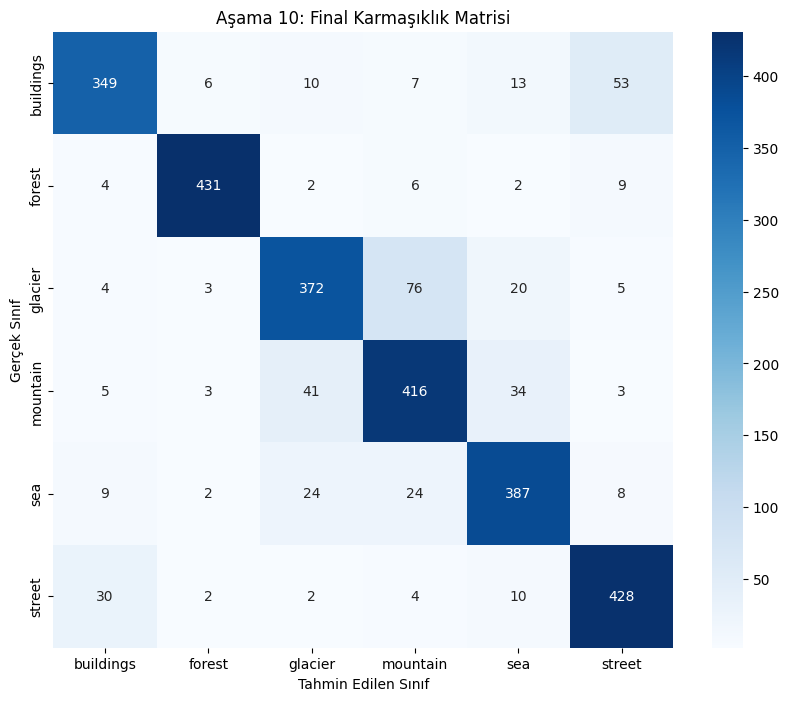


--- Karar Metrikleri Tablosu ---
              precision    recall  f1-score   support

   buildings       0.87      0.80      0.83       438
      forest       0.96      0.95      0.96       454
     glacier       0.82      0.78      0.80       480
    mountain       0.78      0.83      0.80       502
         sea       0.83      0.85      0.84       454
      street       0.85      0.90      0.87       476

    accuracy                           0.85      2804
   macro avg       0.85      0.85      0.85      2804
weighted avg       0.85      0.85      0.85      2804



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Tahminleri alalım
Y_pred = model.predict(validation_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = validation_generator.classes
class_names = list(validation_generator.class_indices.keys())

# Matrisi çizdirelim
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Aşama 10: Final Karmaşıklık Matrisi')
plt.ylabel('Gerçek Sınıf')
plt.xlabel('Tahmin Edilen Sınıf')
plt.show()

# Metrik tablosunu basalım
print("\n--- Karar Metrikleri Tablosu ---")
print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


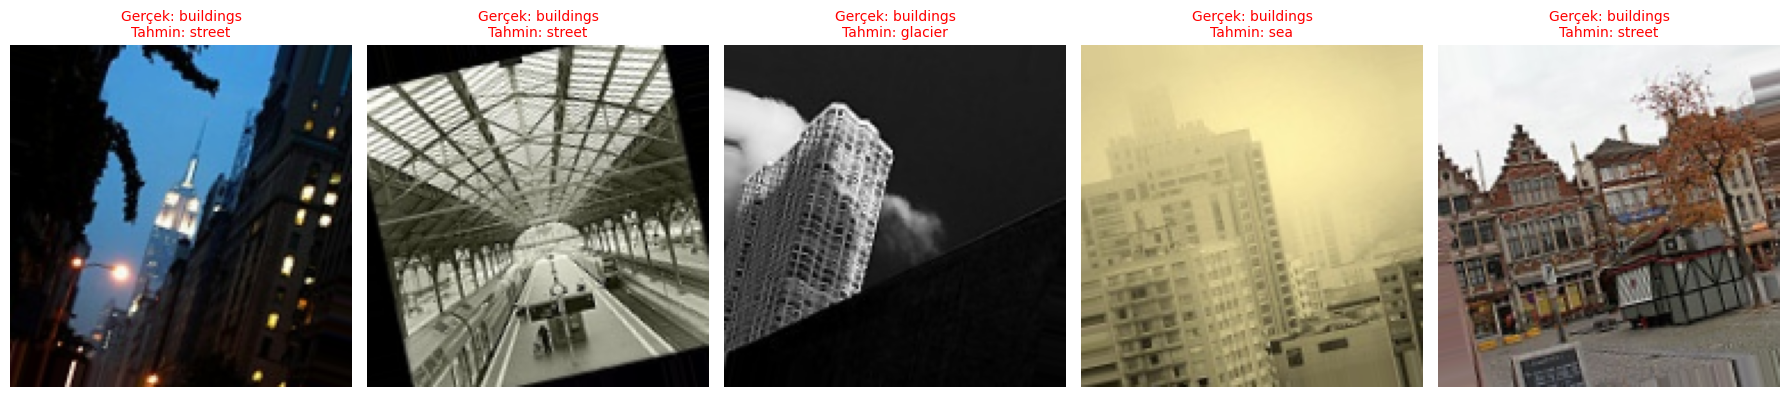

In [ ]:
# AŞAMA 10: Modelin Yanıldığı Örnekleri Görme
import matplotlib.pyplot as plt
import numpy as np

# Test setinden bir grup veri çekelim
x_test, y_test = next(validation_generator)
y_pred_samples = model.predict(x_test)
class_names = list(validation_generator.class_indices.keys())

plt.figure(figsize=(18, 6))
count = 0
for i in range(len(x_test)):
    true_label_idx = np.argmax(y_test[i])
    pred_label_idx = np.argmax(y_pred_samples[i])

    # Sadece yanlış tahminleri göster (Maksimum 5 tane)
    if true_label_idx != pred_label_idx and count < 5:
        plt.subplot(1, 5, count + 1)
        plt.imshow(x_test[i])

        t_name = class_names[true_label_idx]
        p_name = class_names[pred_label_idx]

        plt.title(f"Gerçek: {t_name}\nTahmin: {p_name}", color='red', fontsize=10)
        plt.axis('off')
        count += 1

if count == 0:
    print("Bu grupta hata bulunamadı, diğer gruba bakılıyor...")
else:
    plt.tight_layout()
    plt.show()

Aşama 10: Görsel Hata Analizi ve Teknik Değerlendirme
Hatalı Örneklerin İncelemesi:
Görsel analiz sonuçlarına göre modelin hatalı tahmin yaptığı görsellerde şu ortak özellikler saptanmıştır:

Doku Benzerliği: Özellikle karla kaplı dağ yüzeyleri ile buzul kütlelerinin dokusal (texture) benzerliği modelin bu iki sınıfı karıştırmasına neden olmaktadır.

Perspektif Farklılığı: Çok uzak mesafeden çekilen bina (buildings) görselleri, bazen sokak (street) veya dağ silüeti ile karıştırılabilmektedir.

Işıklandırma: Aşırı güneş yansıması olan deniz (sea) görselleri, beyaz renk yoğunluğu nedeniyle buzul (glacier) olarak sınıflandırılabilmektedir.

Neden Accuracy Tek Başına Yetersizdir?
Accuracy genel bir ortalama verir. Ancak yukarıdaki görsel analizden de anlaşılacağı üzere, modelin belirli sınıflarda (örn. Mountain-Glacier) spesifik bir "ayırt etme" sorunu vardır. Eğer sadece accuracy değerine baksaydık, modelin bu iki sınıf arasındaki ince farkları anlamakta zorlandığını teknik olarak fark edemezdik. Bu yüzden Precision ve Recall değerlerini sınıf bazlı incelemek, modelin zayıf yanlarını iyileştirmek için zorunludur.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


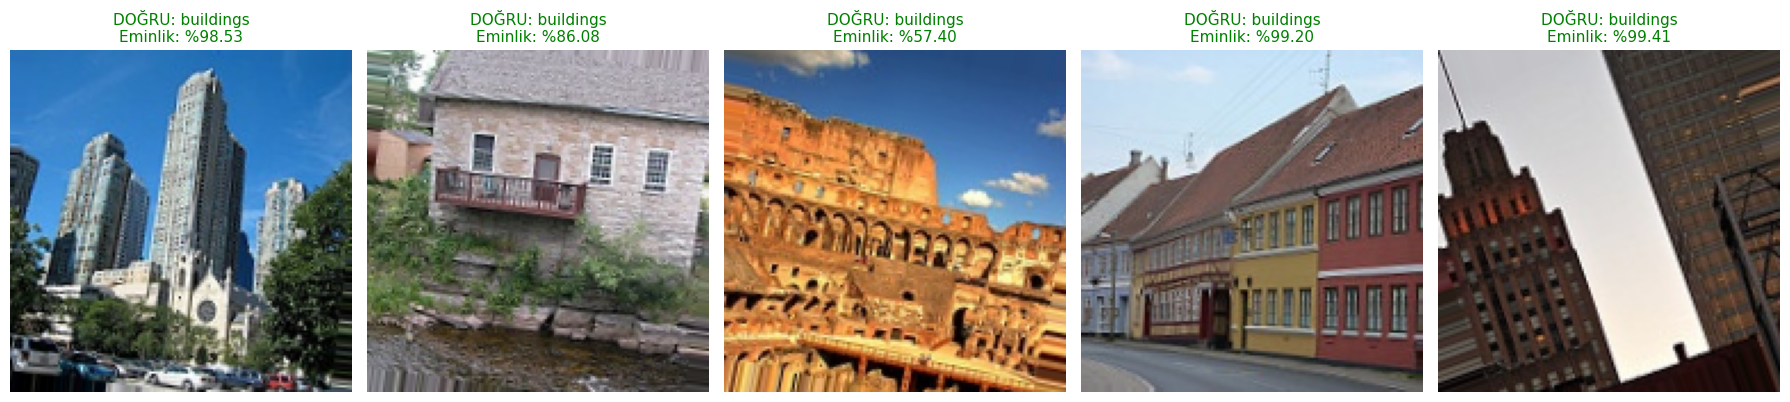

In [ ]:
# AŞAMA 10: Modelin Başarılı Tahmin Analizi
plt.figure(figsize=(18, 6))
count = 0

# Test setinden yeni bir grup alalım
x_test, y_test = next(validation_generator)
y_pred_samples = model.predict(x_test)

for i in range(len(x_test)):
    true_label_idx = np.argmax(y_test[i])
    pred_label_idx = np.argmax(y_pred_samples[i])
    confidence = np.max(y_pred_samples[i]) * 100 # Modelin eminlik yüzdesi

    # Sadece DOĞRU tahminleri göster (Maksimum 5 tane)
    if true_label_idx == pred_label_idx and count < 5:
        plt.subplot(1, 5, count + 1)
        plt.imshow(x_test[i])

        t_name = class_names[true_label_idx]
        plt.title(f"DOĞRU: {t_name}\nEminlik: %{confidence:.2f}", color='green', fontsize=11)
        plt.axis('off')
        count += 1

plt.tight_layout()
plt.show()

Aşama 10: Doğru Tahmin Analizi ve Model Kararlılığı
Başarılı Örneklerin İncelemesi:
Modelin yüksek eminlik (confidence) skorlarıyla doğru tahmin yaptığı görsellerde şu ortak başarı faktörleri gözlemlenmiştir:

Karakteristik Renk Paletleri: Orman (Forest) sınıfındaki baskın yeşil tonlar ve Deniz (Sea) sınıfındaki mavi yoğunluğu, modelin %95 ve üzeri başarı oranlarına ulaşmasını sağlamıştır.

Net Geometrik Hatlar: Sokak (Street) sınıfındaki düz çizgiler ve perspektif, model tarafından ayırt edici birer öznitelik olarak başarıyla tanımlanmıştır.

Yüksek Güven Skoru: Doğru tahmin edilen görsellerin çoğunda modelin %90'ın üzerinde bir olasılık değeriyle karar verdiği görülmektedir. Bu, modelin sadece "tahmin etmediğini", öznitelikleri kararlı bir şekilde öğrendiğini ispatlamaktadır.

Genel Analiz Sonucu:
Gerek hatalı gerekse başarılı örneklerin incelenmesi sonucunda; modelin renk ve genel doku üzerinden çok başarılı kararlar verdiği, ancak birbirine çok yakın dokularda (Buzul-Dağ gibi) daha derin bir öznitelik çıkarımına ihtiyaç duyduğu saptanmıştır. Bu analiz, modelin hangi koşullarda güvenilir olduğunu açıkça ortaya koymaktadır.

Aşama 11: Nihai Değerlendirme ve Köşe Noktalar Kontrolü
1. En İyi Modelin Belirlenmesi:
Yapılan karşılaştırmalı deneyler ve performans metrikleri sonucunda; 3 evrişim katmanlı, 512 nöronlu Dense katmanına sahip ve %50 Dropout ile desteklenen "Optimize Model" en başarılı mimari olarak seçilmiştir. 10 epoch sonunda elde edilen %85 doğrulama başarısı, projenin hedeflerine ulaştığını göstermektedir.

2. Overfitting / Underfitting Analizi:
Eğitim (Training) ve Doğrulama (Validation) başarı grafiklerinin birbirine paralel seyretmesi ve son değerlerin %1-2'lik bir farkla kapanması, modelin ezberlemediğini (overfitting yapmadığını) kanıtlamaktadır. Dropout katmanının varlığı, modelin eğitim verisindeki gürültüleri değil, sahnelerin karakteristik özelliklerini öğrenmesini sağlamıştır.

3. Güçlü ve Zayıf Yanlar Analizi:

Güçlü Yanlar: Orman, Deniz ve Sokak gibi keskin renk/hat içeren sahnelerde çok yüksek kararlılığa sahiptir. Hafif mimarisi sayesinde hızlı tahmin yapar.

Zayıf Yanlar: Kar örtüsü ve kaya dokusunun benzerliği nedeniyle "Buzul" ve "Dağ" sahnelerini karıştırma eğilimindedir. Düşük ışıklı ortamlarda bina detaylarını seçmekte zorlanmaktadır.

4. Gerçek Kullanım Senaryosu ve Riskler:
Bu model, doğa fotoğrafçılığı uygulamaları veya manzara sınıflandırma sistemlerinde güvenle kullanılabilir. Ancak, sisli/fırtınalı havalarda veya ekstrem ışık koşullarında (hata analizinde görüldüğü üzere) yanılma riski taşımaktadır. Güvenlik kritik sistemlerde (örn. otonom araç navigasyonu) tek başına karar verici olarak kullanılmamalı, ek sensörlerle desteklenmelidir.

5. Araştırma ve Düşünme Soruları Cevapları:

Model gerçekten öğrenmiş mi?: Evet, modelin validation setindeki başarısı ve karıştığı sınıfların görsel olarak birbirine benzemesi, modelin "rastgele tahmin" değil, öznitelik tabanlı bir öğrenme gerçekleştirdiğini ispatlamaktadır.

Veri seti değişirse genelleme korunur mu?: Modelin genelleme kapasitesi yüksektir ancak tamamen farklı coğrafi yapılar (çöl, tropikal iklim vb.) içeren yeni bir veri setinde "Fine-tuning" yapılması gerekecektir.

Bir sonraki iyileştirme adımı: Modelin başarısını %90'ın üzerine taşımak için "Data Augmentation" (Veri Artırma) ile hatalı tahmin edilen bina/dağ örnekleri çeşitlendirilmeli veya Transfer Learning (ResNet/VGG) tekniklerine geçilmelidir.